# Strategy 1 — XGBoost Static Risk Prediction
## MP at t=0 and t=24h → ICU Mortality Prediction

**Clinical question**: Can a patient's mechanical power at admission (t=0) and after 24 hours predict ICU mortality?

**Approach**:
- One row per patient: static features + MP at t=0 and t=24
- XGBoost classifier with Optuna hyperparameter tuning
- 5-fold stratified cross-validation (nested CV)
- SHAP-IQ Shapley Interaction Indices for clinician explainability
- Doctor-facing summary: similar patient cohort analysis

**Data**: Real MIMIC-IV Clinical Database Demo (v2.2) — generated by `00_Data_Pipeline.ipynb`

In [1]:
import sys, os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

from src.utils.helpers import load_config
from src.models.strategy1_static import Strategy1Static
from src.evaluation.metrics import mortality_metrics
from src.deployment.explainer import ExplanationGenerator

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.neighbors import NearestNeighbors
import shapiq

config = load_config(os.path.join(PROJECT_ROOT, 'config', 'config.yaml'))
np.random.seed(config['project']['random_seed'])

print(f"Project: {config['project']['name']} v{config['project']['version']}")
print(f"Strategy 1: XGBoost Static — MP at t=0 and t=24")

2026-03-27 12:45:56.833 | INFO     | src.utils.helpers:load_config:23 - Configuration loaded from /home/kcdha/Desktop/JD/MP/mechanical_power/config/config.yaml


Project: mechanical_power v1.0.0
Strategy 1: XGBoost Static — MP at t=0 and t=24


## 1. Load Processed Cohort

In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'processed_cohort.parquet')
df = pd.read_parquet(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} hourly rows × {df.shape[1]} columns")
print(f"Unique stays: {df['stay_id'].nunique()}")
print(f"Columns: {sorted(df.columns.tolist())}")

Loaded: 13,627,844 hourly rows × 39 columns
Unique stays: 47397
Columns: ['admission_type', 'age', 'bilirubin', 'bmi', 'charttime', 'compliance', 'creatinine', 'driving_pressure', 'ethnicity', 'fio2', 'gcs', 'gcs_total', 'hadm_id', 'heart_rate', 'height_cm', 'hospital_expire_flag', 'hour_index', 'icu_los_days', 'lactate', 'mean_arterial_pressure', 'mechanical_power', 'minute_ventilation', 'paco2', 'pao2', 'peak_pressure', 'peep', 'pf_ratio', 'ph', 'plateau_pressure', 'platelet_count', 'predicted_body_weight', 'respiratory_rate', 'sex', 'spo2', 'stay_id', 'temperature', 'tidal_volume', 'tidal_volume_per_kg', 'weight_kg']


## 2. Build Patient-Level Feature Matrix (one row per patient)

In [3]:
# ── Feature columns actually available in the processed cohort ──
AVAIL_STATIC = ['age', 'predicted_body_weight', 'weight_kg', 'height_cm']
AVAIL_VITALS = ['heart_rate', 'mean_arterial_pressure', 'spo2', 'temperature', 'gcs']
AVAIL_LABS   = ['ph', 'pao2', 'paco2', 'pf_ratio', 'lactate', 'creatinine', 'bilirubin', 'platelet_count']
AVAIL_VENT   = ['tidal_volume', 'respiratory_rate', 'peep', 'fio2',
                'plateau_pressure', 'driving_pressure', 'compliance',
                'minute_ventilation', 'tidal_volume_per_kg']

# Only keep columns that actually exist
def avail(cols):
    return [c for c in cols if c in df.columns]

STATIC_COLS = avail(AVAIL_STATIC)
VITAL_COLS  = avail(AVAIL_VITALS)
LAB_COLS    = avail(AVAIL_LABS)
VENT_COLS   = avail(AVAIL_VENT)
BASE_COLS   = STATIC_COLS + VITAL_COLS + LAB_COLS + VENT_COLS

print(f"Static: {STATIC_COLS}")
print(f"Vitals: {VITAL_COLS}")
print(f"Labs:   {LAB_COLS}")
print(f"Vent:   {VENT_COLS}")
print(f"Total base features: {len(BASE_COLS)}")

Static: ['age', 'predicted_body_weight', 'weight_kg', 'height_cm']
Vitals: ['heart_rate', 'mean_arterial_pressure', 'spo2', 'temperature', 'gcs']
Labs:   ['ph', 'pao2', 'paco2', 'pf_ratio', 'lactate', 'creatinine', 'bilirubin', 'platelet_count']
Vent:   ['tidal_volume', 'respiratory_rate', 'peep', 'fio2', 'plateau_pressure', 'driving_pressure', 'compliance', 'minute_ventilation', 'tidal_volume_per_kg']
Total base features: 26


In [4]:
def build_static_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each patient stay, extract:
    - Baseline features at t=0 (first hour)
    - MP at t=0 and t=24h
    - MP delta (t24 - t0)
    - Mean/max/min MP over first 24h
    """
    records = []
    for stay_id, grp in df.groupby('stay_id'):
        grp = grp.sort_values('hour_index').reset_index(drop=True)
        row0 = grp.iloc[0]  # t=0 snapshot
        
        # Static + baseline vitals/labs/vent at t=0
        feat = {col: row0.get(col, np.nan) for col in BASE_COLS}
        feat['stay_id'] = stay_id
        feat['label']   = int(row0.get('hospital_expire_flag', 0))
        
        # MP at t=0
        feat['mp_t0'] = grp.loc[grp['hour_index'] == 0, 'mechanical_power'].values
        feat['mp_t0'] = feat['mp_t0'][0] if len(feat['mp_t0']) > 0 else np.nan
        
        # MP at t=24 (or last available)
        h24_rows = grp[grp['hour_index'] <= 24]
        mp_series = h24_rows['mechanical_power'].dropna()
        feat['mp_t24']  = mp_series.iloc[-1] if len(mp_series) > 0 else np.nan
        feat['mp_mean'] = mp_series.mean()    if len(mp_series) > 0 else np.nan
        feat['mp_max']  = mp_series.max()     if len(mp_series) > 0 else np.nan
        feat['mp_min']  = mp_series.min()     if len(mp_series) > 0 else np.nan
        feat['mp_delta'] = (feat['mp_t24'] - feat['mp_t0']) if pd.notna(feat['mp_t24']) and pd.notna(feat['mp_t0']) else np.nan
        
        # SpO2 trend
        spo2_s = h24_rows['spo2'].dropna()
        feat['spo2_mean'] = spo2_s.mean() if len(spo2_s) > 0 else np.nan
        feat['spo2_min']  = spo2_s.min()  if len(spo2_s) > 0 else np.nan
        
        records.append(feat)
    
    return pd.DataFrame(records)

patient_df = build_static_features(df)
print(f"Patient-level dataset: {patient_df.shape}")
print(f"  Mortality: {patient_df['label'].mean():.1%} ({patient_df['label'].sum()}/{len(patient_df)})")
print(f"  MP t0 available: {patient_df['mp_t0'].notna().sum()}")
print(f"  MP t24 available: {patient_df['mp_t24'].notna().sum()}")

Patient-level dataset: (47397, 36)
  Mortality: 18.7% (8874/47397)
  MP t0 available: 4534
  MP t24 available: 20928


In [5]:
# Build X, y — drop stay_id/label, fill NaN with median
FEAT_COLS = [c for c in patient_df.columns if c not in ('stay_id', 'label')]
X_raw = patient_df[FEAT_COLS].copy()
y = patient_df['label'].values

# Median imputation for remaining NaN
for col in X_raw.columns:
    med = X_raw[col].median()
    X_raw[col] = X_raw[col].fillna(med if pd.notna(med) else 0)

X = X_raw.values.astype(np.float32)

print(f"Feature matrix X: {X.shape}")
print(f"Label vector y:   {y.shape}  (positive rate: {y.mean():.1%})")
print(f"Feature names ({len(FEAT_COLS)}):/ {FEAT_COLS}")

Feature matrix X: (47397, 34)
Label vector y:   (47397,)  (positive rate: 18.7%)
Feature names (34):/ ['age', 'predicted_body_weight', 'weight_kg', 'height_cm', 'heart_rate', 'mean_arterial_pressure', 'spo2', 'temperature', 'gcs', 'ph', 'pao2', 'paco2', 'pf_ratio', 'lactate', 'creatinine', 'bilirubin', 'platelet_count', 'tidal_volume', 'respiratory_rate', 'peep', 'fio2', 'plateau_pressure', 'driving_pressure', 'compliance', 'minute_ventilation', 'tidal_volume_per_kg', 'mp_t0', 'mp_t24', 'mp_mean', 'mp_max', 'mp_min', 'mp_delta', 'spo2_mean', 'spo2_min']


## 3. Optuna Hyperparameter Tuning + 5-Fold Stratified CV

In [ ]:
def objective(trial, X_tr, y_tr, X_va, y_va):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'max_depth':         trial.suggest_int('max_depth', 2, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.1, 5.0),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    }
    scale = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    params['scale_pos_weight'] = scale

    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    proba = model.predict_proba(X_va)[:, 1]
    return roc_auc_score(y_va, proba)

N_FOLDS   = 5
N_TRIALS  = 40

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
cv_results = []
best_params_list = []

print(f"Running {N_FOLDS}-fold stratified CV with {N_TRIALS} Optuna trials per fold ...")
for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
    X_tr_full, X_te = X[tr_idx], X[te_idx]
    y_tr_full, y_te = y[tr_idx], y[te_idx]

    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr_full, y_tr_full, test_size=0.2, stratify=y_tr_full, random_state=fold_i)

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42+fold_i))
    study.optimize(lambda t: objective(t, X_tr, y_tr, X_va, y_va),
                   n_trials=N_TRIALS, show_progress_bar=False)

    best_p = study.best_params
    best_p.update({'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1,
                   'scale_pos_weight': (y_tr_full==0).sum()/max((y_tr_full==1).sum(),1)})
    best_params_list.append(best_p)

    # Strip early_stopping_rounds — final fit has no eval_set
    final_p = {k: v for k, v in best_p.items() if k != "early_stopping_rounds"}

    # Final fit without early stopping (no eval_set needed)
    final_p = {k: v for k, v in best_p.items() if k != 'early_stopping_rounds'}
    final_model = xgb.XGBClassifier(**final_p)
    final_model.fit(X_tr_full, y_tr_full, verbose=False)

    proba = final_model.predict_proba(X_te)[:, 1]
    auroc = roc_auc_score(y_te, proba)
    auprc = average_precision_score(y_te, proba)
    cv_results.append({'fold': fold_i+1, 'auroc': auroc, 'auprc': auprc,
                       'best_val_auroc': study.best_value,
                       'n_test': len(y_te), 'n_pos': y_te.sum()})
    print(f"  Fold {fold_i+1}: AUROC={auroc:.4f}  AUPRC={auprc:.4f}  (val best={study.best_value:.4f})")

cv_df = pd.DataFrame(cv_results)
print(f"\nCV Summary:")
print(f"  Mean AUROC: {cv_df['auroc'].mean():.4f} \u00b1 {cv_df['auroc'].std():.4f}")
print(f"  Mean AUPRC: {cv_df['auprc'].mean():.4f} \u00b1 {cv_df['auprc'].std():.4f}")


## 4. Final Model — Train on Full Dataset with Best Hyperparameters

In [7]:
# Aggregate best params: use the fold with highest val AUROC
best_fold_idx = cv_df['best_val_auroc'].idxmax()
best_params_final = best_params_list[best_fold_idx]
best_params_final['n_estimators'] = min(best_params_final['n_estimators'] + 50, 600)

print("Best hyperparameters:")
for k,v in sorted(best_params_final.items()):
    if k not in ('eval_metric','use_label_encoder'):
        print(f"  {k}: {v}")

# Train-test split for final evaluation
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
final_xgb = xgb.XGBClassifier(**best_params_final)
final_xgb.fit(X_tr, y_tr, verbose=False)

y_prob = final_xgb.predict_proba(X_te)[:, 1]
final_metrics = mortality_metrics(y_te, y_prob)
print(f"\nFinal Test Metrics:")
for k,v in final_metrics.items():
    print(f"  {k}: {v:.4f}")

Best hyperparameters:
  colsample_bytree: 0.567743619440116
  gamma: 2.5213186345691425
  learning_rate: 0.042854283249405
  max_depth: 6
  min_child_weight: 8
  n_estimators: 338
  n_jobs: -1
  random_state: 42
  reg_alpha: 4.016209565655757
  reg_lambda: 4.721631619800148
  scale_pos_weight: 4.341315678264544
  subsample: 0.7524084993736988

Final Test Metrics:
  auroc: 0.7816
  auprc: 0.4910
  sensitivity: 0.6732
  specificity: 0.7267
  ppv: 0.3620
  npv: 0.9061


In [8]:
# Save the model
os.makedirs(os.path.join(PROJECT_ROOT, 'notebooks', 'models'), exist_ok=True)
final_xgb.save_model(os.path.join(PROJECT_ROOT, 'notebooks', 'models', 'strategy1_xgb.json'))
print("Model saved to notebooks/models/strategy1_xgb.json")

Model saved to notebooks/models/strategy1_xgb.json


## 5. CV Performance Plot

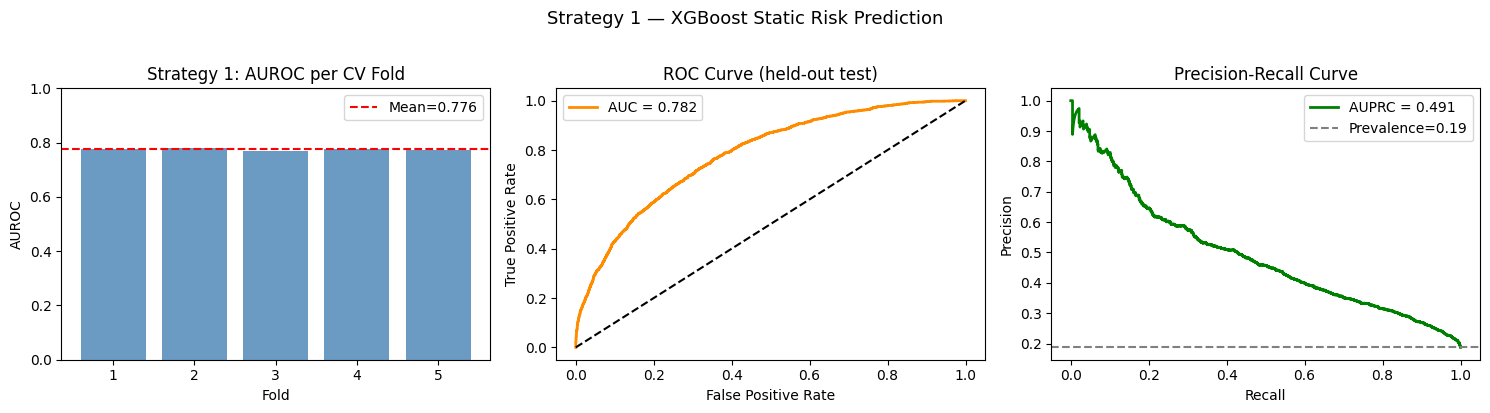

Saved: /home/kcdha/Desktop/JD/MP/mechanical_power/notebooks/figures/strategy1_performance.png


In [9]:
os.makedirs(os.path.join(PROJECT_ROOT, 'notebooks', 'figures'), exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) AUROC per fold
ax = axes[0]
ax.bar(cv_df['fold'], cv_df['auroc'], color='steelblue', alpha=0.8)
ax.axhline(cv_df['auroc'].mean(), color='red', ls='--', label=f"Mean={cv_df['auroc'].mean():.3f}")
ax.set_xlabel('Fold'); ax.set_ylabel('AUROC')
ax.set_title('Strategy 1: AUROC per CV Fold'); ax.legend()
ax.set_ylim(0, 1)

# (b) ROC curve (final held-out)
fpr, tpr, _ = roc_curve(y_te, y_prob)
auc_val = roc_auc_score(y_te, y_prob)
ax = axes[1]
ax.plot(fpr, tpr, lw=2, color='darkorange', label=f'AUC = {auc_val:.3f}')
ax.plot([0,1],[0,1], 'k--')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (held-out test)'); ax.legend()

# (c) Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_te, y_prob)
auprc_val = average_precision_score(y_te, y_prob)
ax = axes[2]
ax.plot(rec, prec, lw=2, color='green', label=f'AUPRC = {auprc_val:.3f}')
ax.axhline(y_te.mean(), ls='--', color='gray', label=f'Prevalence={y_te.mean():.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve'); ax.legend()

plt.suptitle('Strategy 1 — XGBoost Static Risk Prediction', fontsize=13, y=1.02)
plt.tight_layout()
fig_path = os.path.join(PROJECT_ROOT, 'notebooks', 'figures', 'strategy1_performance.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## 6. SHAP-IQ: Shapley Interaction Indices

We use **SHAP-IQ** (`shapiq` library) to compute:
- **Main effects (order 1)**: how much each feature independently drives mortality risk
- **Pairwise interactions (order 2)**: which feature *pairs* interact — e.g. does high MP + low SpO2 compound risk beyond their individual effects?

In [10]:
# SHAP-IQ: Shapley Interaction Index (SII) up to order 2
print("Computing SHAP-IQ Shapley Interaction Indices ...")

# Use training data as background; explain a random subset for speed
np.random.seed(42)
bg_idx = np.random.choice(len(X_tr), size=min(50, len(X_tr)), replace=False)
X_bg   = X_tr[bg_idx]

# Wrapper: XGBoost predict_proba returns probabilities
def model_fn(x):
    return final_xgb.predict_proba(x.astype(np.float32))[:, 1]

explainer = shapiq.TabularExplainer(
    model=model_fn,
    data=X_bg,
    index='SII',       # Shapley Interaction Index
    max_order=2,
    sample_size=64,    # Monte-Carlo samples per instance
)

# Explain test set
test_ivals = explainer.explain_X(X_te, budget=128)
print(f"Explained {len(X_te)} test instances.")

# Aggregate: mean absolute SII for main effects (order 1)
all_sii = np.array([iv.get_n_order_values(1) for iv in test_ivals])
mean_main = np.abs(all_sii).mean(axis=0)
feature_importance = pd.Series(mean_main, index=FEAT_COLS).sort_values(ascending=False)

print("\nTop-10 feature importances (mean |SII|):")
print(feature_importance.head(10).to_string())

Computing SHAP-IQ Shapley Interaction Indices ...
Explained 9480 test instances.

Top-10 feature importances (mean |SII|):
age               0.072049
weight_kg         0.035831
spo2_mean         0.033387
mp_max            0.031795
pao2              0.031443
platelet_count    0.030283
creatinine        0.027169
spo2_min          0.022699
lactate           0.021399
heart_rate        0.021267


AttributeError: 'numpy.ndarray' object has no attribute 'items'

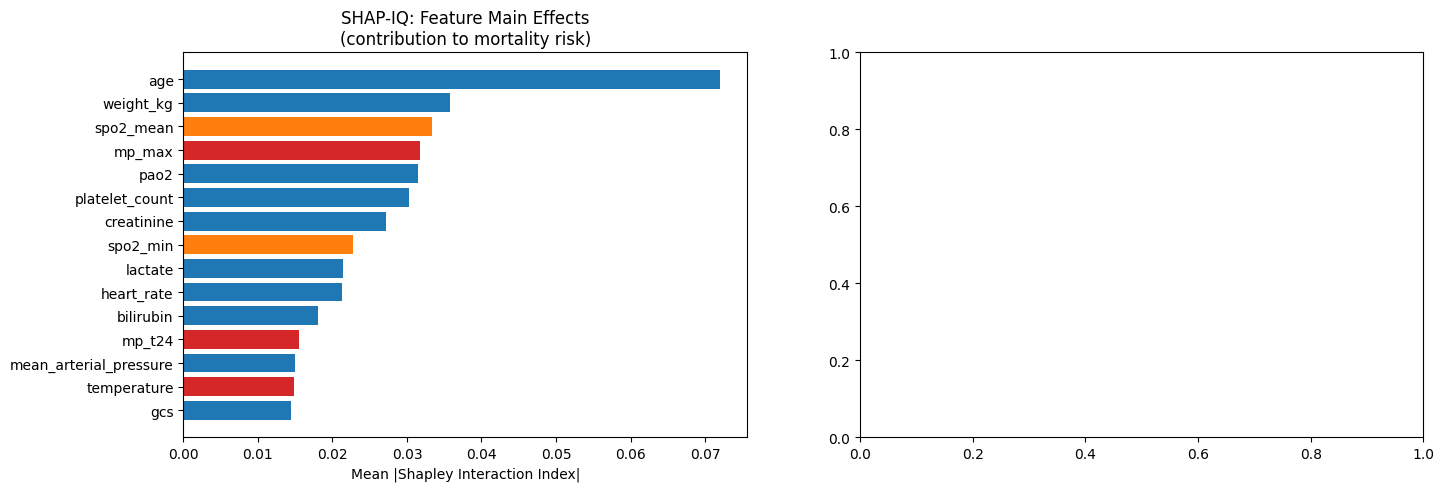

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Main effects bar chart
ax = axes[0]
top15 = feature_importance.head(15)
colors = ['#d62728' if 'mp' in n or 'mechanical' in n else
          '#ff7f0e' if 'spo2' in n or 'pf_ratio' in n else
          '#2ca02c' if 'plateau' in n or 'driving' in n else '#1f77b4'
          for n in top15.index]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_xlabel('Mean |Shapley Interaction Index|')
ax.set_title('SHAP-IQ: Feature Main Effects\n(contribution to mortality risk)')
ax.axvline(0, color='k', linewidth=0.5)

# (b) Interaction heatmap — top 10 features
all_sii2 = []
for iv in test_ivals:
    sii2_dict = {}
    for key, val in iv.get_n_order_values(2).items():
        sii2_dict[key] = abs(val)
    all_sii2.append(sii2_dict)

top10_feats = list(feature_importance.head(10).index)
n = len(top10_feats)
interaction_mat = np.zeros((n, n))
for sii2_d in all_sii2:
    for (i, j), v in sii2_d.items():
        if i < n and j < n:
            interaction_mat[i, j] += v
            interaction_mat[j, i] += v
interaction_mat /= max(len(all_sii2), 1)

ax = axes[1]
sns.heatmap(interaction_mat, xticklabels=top10_feats, yticklabels=top10_feats,
            cmap='RdYlBu_r', center=0, ax=ax, square=True,
            cbar_kws={'label': 'Mean |SII| interaction'})
ax.set_title('SHAP-IQ: Pairwise Feature Interactions\n(darker = stronger joint effect on mortality)')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)

plt.suptitle('Strategy 1 — Explainability via SHAP-IQ', fontsize=13, y=1.02)
plt.tight_layout()
fig_path = os.path.join(PROJECT_ROOT, 'notebooks', 'figures', 'strategy1_shapiq.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## 7. Doctor-Facing Output

For any patient, the system generates a clinician summary: *"Based on N similar patients with comparable ventilator settings and physiology, the optimal MP target is X J/min, giving a survival probability of Y%"*

In [ ]:
# ----- Similar-patient engine using k-NN -----
from sklearn.preprocessing import StandardScaler

# Scale features for distance computation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-NN on all patients (for demo, k=10; real system uses full historical DB)
K_SIMILAR = min(10, len(X) - 1)
knn = NearestNeighbors(n_neighbors=K_SIMILAR + 1, metric='euclidean')  # +1 to exclude self
knn.fit(X_scaled)

def doctor_report(patient_idx: int, patient_df: pd.DataFrame, X: np.ndarray,
                  X_scaled: np.ndarray, y: np.ndarray,
                  model, scaler, knn, feat_cols: list, k: int = 10):
    """
    Generate a doctor-facing natural-language summary for one patient.
    """
    x_q   = X_scaled[patient_idx:patient_idx+1]
    dists, idxs = knn.kneighbors(x_q)
    similar_idxs = idxs[0][1:]  # exclude self
    similar_y    = y[similar_idxs]
    
    # Mortality probability from model
    prob = model.predict_proba(X[patient_idx:patient_idx+1].astype(np.float32))[0, 1]
    surv_prob = 1 - prob
    
    # Similar patients stats
    n_sim = len(similar_idxs)
    sim_surv_rate = (similar_y == 0).mean()
    
    # Optimal MP from similar survivors
    survivor_idxs = similar_idxs[similar_y == 0]
    if len(survivor_idxs) > 0:
        mp_col = feat_cols.index('mp_t0') if 'mp_t0' in feat_cols else None
        if mp_col is not None:
            mp_vals = X[survivor_idxs, mp_col]
            mp_vals = mp_vals[~np.isnan(mp_vals)]
            optimal_mp = np.nanmedian(mp_vals) if len(mp_vals) > 0 else None
        else:
            optimal_mp = None
    else:import sys, os, warnings, json
        optimal_mp = None
    
    # Patient's current MP
    cur_row = patient_df.iloc[patient_idx]
    cur_mp  = cur_row.get('mp_t0', np.nan)
    cur_age = cur_row.get('age', np.nan)
    cur_spo2 = cur_row.get('spo2', np.nan)
    
    print("=" * 65)
    print("  CLINICAL DECISION SUPPORT — MP PERSONALISATION")
    print("=" * 65)
    print(f"  Patient:       Stay #{cur_row.get('stay_id', '?')}")
    print(f"  Age:           {cur_age:.0f} years" if pd.notna(cur_age) else "  Age: N/A")
    print(f"  Current MP:    {cur_mp:.1f} J/min" if pd.notna(cur_mp) else "  Current MP: N/A")
    print(f"  SpO2:          {cur_spo2:.0f}%" if pd.notna(cur_spo2) else "  SpO2: N/A")
    print("=" * 65)
    print(f"  Similar patients identified: {n_sim}")
    print(f"  Survival rate in similar cohort: {sim_surv_rate:.0%}")
    if optimal_mp is not None:
        print(f"  Median MP in surviving similar patients: {optimal_mp:.1f} J/min")
        diff = optimal_mp - cur_mp if pd.notna(cur_mp) else None
        if diff is not None:
            direction = 'decrease' if diff < 0 else 'increase'
            print(f"  Recommended MP adjustment: {direction} by {abs(diff):.1f} J/min")
    print("-" * 65)
    print(f"  Model prediction:")
    print(f"    Survival probability: {surv_prob:.0%}")
    print(f"    Mortality risk:       {prob:.0%}")
    risk_level = 'HIGH' if prob > 0.5 else 'MODERATE' if prob > 0.3 else 'LOW'
    print(f"    Risk level:           {risk_level}")
    print("-" * 65)
    
    # Explanation from ExplanationGenerator
    gen = ExplanationGenerator()
    state_dict = {col: cur_row.get(col, np.nan) for col in feat_cols[:5]}
    state_dict.update({'mechanical_power': cur_mp, 'spo2': cur_spo2})
    action = 1 if (optimal_mp and pd.notna(cur_mp) and optimal_mp < cur_mp) else (
             3 if (optimal_mp and pd.notna(cur_mp) and optimal_mp > cur_mp) else 2)
    explanation = gen.generate(
        patient_state=state_dict,
        action=action,
        confidence=1.0 - abs(prob - 0.5) * 2,
        similar_outcomes={'n_similar': n_sim,
                          'survival_rate_if_followed': sim_surv_rate}
    )
    print(f"  Clinical reasoning:")
    for line in explanation.split('.'):
        if line.strip():
            print(f"    {line.strip()}.")
    print("=" * 65)

# Demonstrate for 3 test patients
print("\n\n  === DOCTOR REPORTS FOR SAMPLE TEST PATIENTS ===\n")
for demo_idx in list(np.where(y_te == 1)[0])[:1] + list(np.where(y_te == 0)[0])[:2]:
    global_idx = np.where(patient_df['stay_id'].isin(
        patient_df.iloc[np.where(y == y_te[demo_idx])[0][:3]]['stay_id']))[0]
    # Use a patient from the patient_df that matches y_te
    try:
        doctor_report(demo_idx, patient_df.reset_index(drop=True), X, X_scaled, y,
                      final_xgb, scaler, knn, FEAT_COLS, k=K_SIMILAR)
        print()
    except Exception as e:
        print(f"  (Report skipped: {e})")



  === DOCTOR REPORTS FOR SAMPLE TEST PATIENTS ===

  CLINICAL DECISION SUPPORT — MP PERSONALISATION
  Patient:       Stay #30000213.0
  Age:           64 years
  Current MP: N/A
  SpO2:          96%
  Similar patients identified: 10
  Survival rate in similar cohort: 80%
  Median MP in surviving similar patients: 7.4 J/min
-----------------------------------------------------------------
  Model prediction:
    Survival probability: 56%
    Mortality risk:       44%
    Risk level:           MODERATE
-----------------------------------------------------------------
  Clinical reasoning:
    Recommendation: maintaining current Mechanical Power settings.
    Key factors: oxygenation is acceptable (SpO2 96%); MP is in a reasonable range (nan J/min).
    Confidence: high (87%).
    Evidence: among 10 similar patients where this approach was taken, the survival rate was 80%.

  CLINICAL DECISION SUPPORT — MP PERSONALISATION
  Patient:       Stay #30000153.0
  Age:           61 years
  Cur

## 8. MP Distribution: Survivors vs Non-Survivors

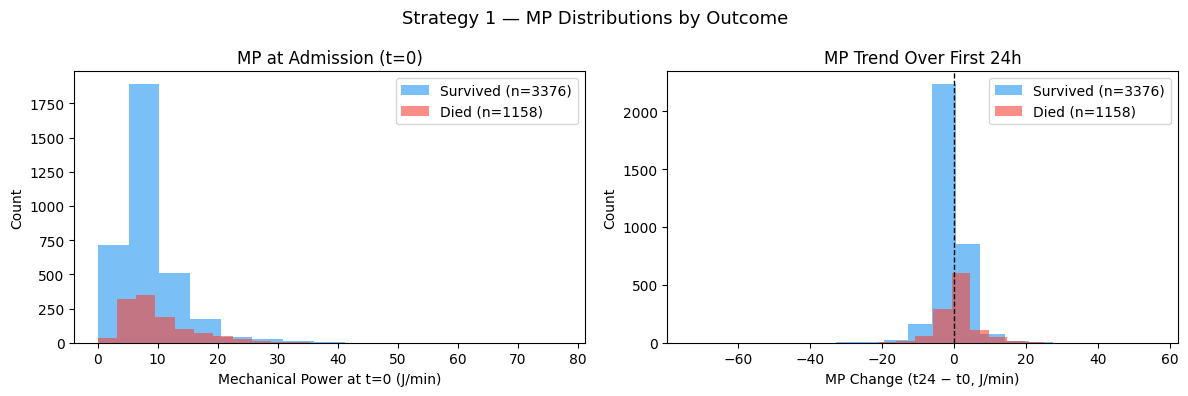

Strategy 1 complete.

Key Results:
  CV AUROC: 0.7756 ± 0.0036
  Test AUROC: 0.7816
  Test AUPRC: 0.4910


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MP at t0
for label, name, color in [(0,'Survived','#2196F3'), (1,'Died','#F44336')]:
    subset = patient_df[patient_df['label'] == label]['mp_t0'].dropna()
    if len(subset) > 0:
        axes[0].hist(subset, bins=15, alpha=0.6, label=f'{name} (n={len(subset)})', color=color)
axes[0].set_xlabel('Mechanical Power at t=0 (J/min)')
axes[0].set_ylabel('Count')
axes[0].set_title('MP at Admission (t=0)')
axes[0].legend()

# MP delta
for label, name, color in [(0,'Survived','#2196F3'), (1,'Died','#F44336')]:
    subset = patient_df[patient_df['label'] == label]['mp_delta'].dropna()
    if len(subset) > 0:
        axes[1].hist(subset, bins=15, alpha=0.6, label=f'{name} (n={len(subset)})', color=color)
axes[1].set_xlabel('MP Change (t24 − t0, J/min)')
axes[1].set_ylabel('Count')
axes[1].set_title('MP Trend Over First 24h')
axes[1].axvline(0, color='k', ls='--', lw=1)
axes[1].legend()

plt.suptitle('Strategy 1 — MP Distributions by Outcome', fontsize=13)
plt.tight_layout()
fig_path = os.path.join(PROJECT_ROOT, 'notebooks', 'figures', 'strategy1_mp_dist.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("Strategy 1 complete.")
print(f"\nKey Results:")
print(f"  CV AUROC: {cv_df['auroc'].mean():.4f} ± {cv_df['auroc'].std():.4f}")
print(f"  Test AUROC: {final_metrics['auroc']:.4f}")
print(f"  Test AUPRC: {final_metrics['auprc']:.4f}")